In [1]:
# Install gdown for downloading from Google Drive
!pip install gdown -q

In [2]:
import os
import glob
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import numpy as np
import zipfile
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import random
import torch.nn as nn
import torch.nn.functional as F

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Google Drive file ID extracted from the provided link
gdrive_file_id = '1PCeClx-rhn4QbKi1-XS5UY7JC8iYoA1Q'
output_zip_name = 'train_test_val_dataset.zip'
destination_path = '/content/dataset_images'

print(f"Downloading dataset from Google Drive (ID: {gdrive_file_id})...")
!gdown --id {gdrive_file_id} -O {output_zip_name}
print("Download complete.")

# Check if the zip file exists before proceeding
if os.path.exists(output_zip_name):
    !mkdir -p {destination_path}
    !unzip -q {output_zip_name} -d {destination_path}

    # Adjust the image_dir path to where your actual images are after unzipping
    image_dir = destination_path

    if os.path.exists(image_dir):
        # Change this if you images are not jpgs (eg. png)
        image_files = glob.glob(os.path.join(image_dir, '**', '*.jpg'), recursive=True)

        print(f"Found {len(image_files)} image files in '{image_dir}' and its subdirectories.")
    else:
        print(f"Image directory '{image_dir}' not found after unzipping. Please check the folder structure inside the zip.")
else:
    print(f"Error: The downloaded file '{output_zip_name}' was not found. Please ensure the Google Drive ID is correct and the file is accessible.")

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1PCeClx-rhn4QbKi1-XS5UY7JC8iYoA1Q
From (redirected): https://drive.google.com/uc?id=1PCeClx-rhn4QbKi1-XS5UY7JC8iYoA1Q&confirm=t&uuid=65fe16b7-73ee-4fbe-94f2-b9a75cf47116
To: /content/train_test_val_dataset.zip
100% 113M/113M [00:00<00:00, 149MB/s] 
Download complete.
Found 0 image files in '/content/dataset_images' and its subdirectories.


In [4]:
# Use existing variables from the notebook state to get the base directory of images
destination_path = '/content/dataset_images'

# Define splits
splits = ['train', 'valid', 'test']

# --- NEW: Unzip nested annotation archives ---
print("Checking for and unzipping nested annotation archives...")
for split_name in splits:
    # Assuming the structure is /content/dataset_images/OxfordPets/{split_name}.zip
    nested_zip_path = os.path.join(destination_path, 'OxfordPets', f'{split_name}.zip')
    # Unzip into the corresponding split directory, e.g., /content/dataset_images/train/
    extract_to_path = os.path.join(destination_path, split_name)

    if os.path.exists(nested_zip_path):
        print(f"Found {split_name}.zip at {nested_zip_path}. Unzipping to {extract_to_path}...")
        os.makedirs(extract_to_path, exist_ok=True) # Ensure target directory exists
        with zipfile.ZipFile(nested_zip_path, 'r') as zip_ref:
            zip_ref.extractall(extract_to_path)
        print(f"Unzipping of {split_name}.zip complete.")
    else:
        print(f"Warning: {split_name}.zip not found at {nested_zip_path}. Skipping unzipping for this split.")
print("Finished checking and unzipping nested archives.\n")
# --- END NEW ---

# Re-glob for completeness *after* unzipping, ensuring we have all image files
all_image_files = glob.glob(os.path.join(destination_path, '**', '*.jpg'), recursive=True)

# Create a mapping from base filename to its full path to resolve annotation paths
image_path_map = {}
for img_file_full_path in all_image_files:
    base_filename = os.path.basename(img_file_full_path)
    image_path_map[base_filename] = img_file_full_path

# Dictionaries to hold annotations for each split
annotations_data_splits = {split: {} for split in splits}
annotated_image_paths_splits = {split: [] for split in splits}

for split in splits:
    split_dir = os.path.join(destination_path, split)
    annotations_file_path = None
    # Recursively search for _annotations.txt within the split directory
    found_annotations = glob.glob(os.path.join(split_dir, '**', '_annotations.txt'), recursive=True)

    if found_annotations:
        annotations_file_path = found_annotations[0]
        print(f"Found _annotations.txt for {split} split at: {annotations_file_path}")

        with open(annotations_file_path, 'r') as f:
            for line in f:
                # Split on the first space to separate image path from annotations string
                parts = line.strip().split(maxsplit=1)

                if len(parts) == 2:
                    base_filename_from_annotation = parts[0]

                    # Use the mapping to get the correct full image path
                    if base_filename_from_annotation in image_path_map:
                        full_image_path = image_path_map[base_filename_from_annotation]
                    else:
                        print(f"Image '{base_filename_from_annotation}' specified in annotations for {split} not found in dataset. Skipping annotation for this image.")
                        continue

                    # The second part might contain multiple bounding box annotations separated by spaces
                    individual_bbox_strings = parts[1].split(' ')

                    # Ensure that the image exists before trying to open it for dimensions
                    if not os.path.exists(full_image_path):
                        print(f"Image not found for annotation: {full_image_path} in {split} split. Skipping all annotations for this image.")
                        continue

                    try:
                        with Image.open(full_image_path) as img:
                            img_width, img_height = img.size

                        for bbox_str in individual_bbox_strings:
                            bbox_and_class_str_list = bbox_str.split(',')
                            if len(bbox_and_class_str_list) != 5:
                                print(f"Skipping malformed bbox/class string (expected 5 values): {bbox_str} in line: {line.strip()} for {split} split.")
                                continue

                            # x_min, y_min, x_max, y_max, class_id are expected as absolute pixel values
                            xmin_abs, ymin_abs, xmax_abs, ymax_abs, class_id = [int(s) for s in bbox_and_class_str_list]

                            # Normalize bounding box coordinates to [0, 1]
                            xmin_norm = xmin_abs / img_width
                            ymin_norm = ymin_abs / img_height
                            xmax_norm = xmax_abs / img_width
                            ymax_norm = ymax_abs / img_height

                            # Clamp normalized coordinates to [0, 1] to handle potential out-of-bounds annotations
                            xmin_norm = max(0.0, min(1.0, xmin_norm))
                            ymin_norm = max(0.0, min(1.0, ymin_norm))
                            xmax_norm = max(0.0, min(1.0, xmax_norm))
                            ymax_norm = max(0.0, min(1.0, ymax_norm))

                            bbox_norm = [xmin_norm, ymin_norm, xmax_norm, ymax_norm] # Normalized [0,1] bounding box coordinates

                            if full_image_path not in annotations_data_splits[split]:
                                annotations_data_splits[split][full_image_path] = {'boxes': [], 'labels': []}
                            annotations_data_splits[split][full_image_path]['boxes'].append(bbox_norm)
                            annotations_data_splits[split][full_image_path]['labels'].append(class_id)
                    except Exception as e: # Catch a broader exception for parsing errors
                        print(f"Skipping line in annotations for {split} due to parsing error: {line.strip()} - Error: {e}")
                else:
                    print(f"Skipping malformed line in annotations for {split} (expected 2 parts after first split): {line.strip()}")
    else:
        print(f"Warning: _annotations.txt not found for {split} split in {split_dir}.")

    # Populate annotated_image_paths_splits for the current split
    annotated_image_paths_splits[split] = list(annotations_data_splits[split].keys())

    if not annotated_image_paths_splits[split]:
        print(f"Warning: No annotated images found for {split} split. The dataset for this split will be empty.")

# Helper function to convert normalized bounding box coordinates to absolute pixel values
def unnormalize_bbox(bbox, width, height):
    # bbox: [x_min, y_min, x_max, y_max] normalized (0-1)
    # Returns: [x_min_abs, y_min_abs, x_max_abs, y_max_abs] absolute pixel values
    x_min, y_min, x_max, y_max = bbox
    x_min_abs = x_min * width
    y_min_abs = y_min * height
    x_max_abs = x_max * width
    y_max_abs = y_max * height
    return [x_min_abs, y_min_abs, x_max_abs, y_max_abs]

# 3. Define a custom PyTorch Dataset for image classification and object localization
class CustomImageLocalizationDataset(Dataset):
    def __init__(self, image_paths, annotations, transform=None):
        self.image_paths = image_paths
        self.annotations = annotations
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert("RGB")

        # Get annotations for this image
        target = self.annotations.get(img_path, {'boxes': [], 'labels': []})

        # Boxes are already normalized [0, 1] as stored in self.annotations
        boxes = torch.as_tensor(target['boxes'], dtype=torch.float32)
        labels = torch.as_tensor(target['labels'], dtype=torch.int64)

        # If there are no boxes, create dummy tensors.
        if boxes.numel() == 0:
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)

        # Store original image dimensions
        img_width, img_height = image.size
        original_size = torch.tensor([img_width, img_height], dtype=torch.float32)

        # Combine boxes and labels into a dictionary, including original_size
        # Boxes are returned as normalized [0,1] values, consistent with model output
        target_dict = {"boxes": boxes, "labels": labels, "original_size": original_size}

        if self.transform:
            image = self.transform(image)

        return image, target_dict

# 4. Define transformations for image preprocessing
data_transform = transforms.Compose([
    transforms.Resize((224, 224)), # Resize images to a common size for model input
    transforms.ToTensor(),         # Convert PIL Image to PyTorch Tensor (scales pixel values to 0-1)
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # Standard ImageNet normalization
])

# 5. Custom collate_fn for object detection
# Object detection models usually expect a list of images and a list of targets (dicts)
# because bounding box counts can vary per image in a batch.
def collate_fn(batch):
    return tuple(zip(*batch))

# 6. Create the dataset and DataLoader instances for each split
datasets = {}
data_loaders = {}
batch_size = 8 # Define batch size for the DataLoader

for split in splits:
    datasets[split] = CustomImageLocalizationDataset(
        image_paths=annotated_image_paths_splits[split],
        annotations=annotations_data_splits[split],
        transform=data_transform
    )
    data_loaders[split] = DataLoader(
        datasets[split],
        batch_size=batch_size,
        shuffle=(split == 'train'), # Only shuffle training data
        num_workers=2,
        collate_fn=collate_fn
    )
    print(f"Successfully created PyTorch Dataset for {split} split with {len(datasets[split])} annotated samples.")
    print(f"Created DataLoader for {split} split with batch size {batch_size}.")

# Example: Iterate through the DataLoader to verify the loaded data structure
# Modified to check first batch for each split
for split in splits:
    if len(datasets[split]) > 0:
        print(f"\nVerifying data loading for {split} split (first batch):")
        for i, (images, targets) in enumerate(data_loaders[split]):
            print(f"Batch {i+1} for {split} split:")
            print(f"  Number of images in batch: {len(images)}")
            print(f"  Shape of first image tensor: {images[0].shape}") # Expected: [C, H, W] after transforms
            print(f"  Targets for first image in batch: {targets[0]}")

            if targets[0]['boxes'].numel() > 0:
                print(f"  First bounding box (x_min, y_min, x_max, y_max) normalized: {targets[0]['boxes'][0].tolist()}")
                print(f"  Corresponding label: {targets[0]['labels'][0].item()} (0=cat, 1=dog)")
                print(f"  Original image size: {targets[0]['original_size'].tolist()}")
                # Now the bounding boxes are normalized, so their max value should be <= 1.0
                if targets[0]['boxes'][0].max() > 1.0 or targets[0]['boxes'][0].min() < 0.0:
                    print("Warning: Bounding box coordinates are unexpectedly out of [0, 1] range.")
            else:
                print(f"  No bounding boxes found for the first image in this batch for {split} split.")
            break # Only process the first batch for verification
    else:
        print(f"The {split} dataset is empty, so DataLoader for {split} will also be empty.")


Checking for and unzipping nested annotation archives...
Found train.zip at /content/dataset_images/OxfordPets/train.zip. Unzipping to /content/dataset_images/train...
Unzipping of train.zip complete.
Found valid.zip at /content/dataset_images/OxfordPets/valid.zip. Unzipping to /content/dataset_images/valid...
Unzipping of valid.zip complete.
Found test.zip at /content/dataset_images/OxfordPets/test.zip. Unzipping to /content/dataset_images/test...
Unzipping of test.zip complete.
Finished checking and unzipping nested archives.

Found _annotations.txt for train split at: /content/dataset_images/train/train/_annotations.txt
Found _annotations.txt for valid split at: /content/dataset_images/valid/valid/_annotations.txt
Found _annotations.txt for test split at: /content/dataset_images/test/test/_annotations.txt
Successfully created PyTorch Dataset for train split with 2576 annotated samples.
Created DataLoader for train split with batch size 8.
Successfully created PyTorch Dataset for val

In [5]:
def visualize_random_image_with_bboxes(datasets, split_name):
    """
    Visualizes a random image from the specified dataset split with its bounding boxes and labels.

    Args:
        datasets (dict): A dictionary containing PyTorch CustomImageLocalizationDataset instances for different splits.
        split_name (str): The name of the split to visualize (e.g., 'train', 'valid', 'test').
    """
    if split_name not in datasets:
        print(f"Error: Split '{split_name}' not found in datasets.")
        return

    dataset = datasets[split_name]

    if len(dataset) == 0:
        print(f"No images in the '{split_name}' dataset to visualize.")
        return

    # Get a random image index
    random_idx = random.randint(0, len(dataset) - 1)

    # Get the image path and annotations for visualization
    img_path = dataset.image_paths[random_idx]
    original_image = Image.open(img_path).convert("RGB")
    target = dataset.annotations.get(img_path, {'boxes': [], 'labels': []})

    # Define class labels for visualization
    class_names = {0: 'cat', 1: 'dog'}

    # Plot the image and bounding boxes
    fig, ax = plt.subplots(1, figsize=(10, 10))
    ax.imshow(original_image)

    img_width, img_height = original_image.size

    boxes_to_plot = []
    if 'boxes' in target and target['boxes']:
        for box_norm in target['boxes']:
            # `unnormalize_bbox` is a helper function defined earlier in the notebook, assumed to be in scope
            boxes_to_plot.append(unnormalize_bbox(box_norm, float(img_width), float(img_height)))

    labels_to_plot = target.get('labels', [])

    for i, box in enumerate(boxes_to_plot):
        xmin, ymin, xmax, ymax = box
        label = labels_to_plot[i]
        class_name = class_names.get(label, 'Unknown')

        # Create a Rectangle patch
        rect = patches.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin,
                                 linewidth=2, edgecolor='r', facecolor='none')
        ax.add_patch(rect)

        # Add label
        plt.text(xmin, ymin - 10, class_name, color='red', fontsize=12,
                 bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

    ax.set_title(f"Sample Image with Bounding Boxes from {split_name} Split (Image ID: {random_idx})")
    plt.axis('off')
    plt.show()

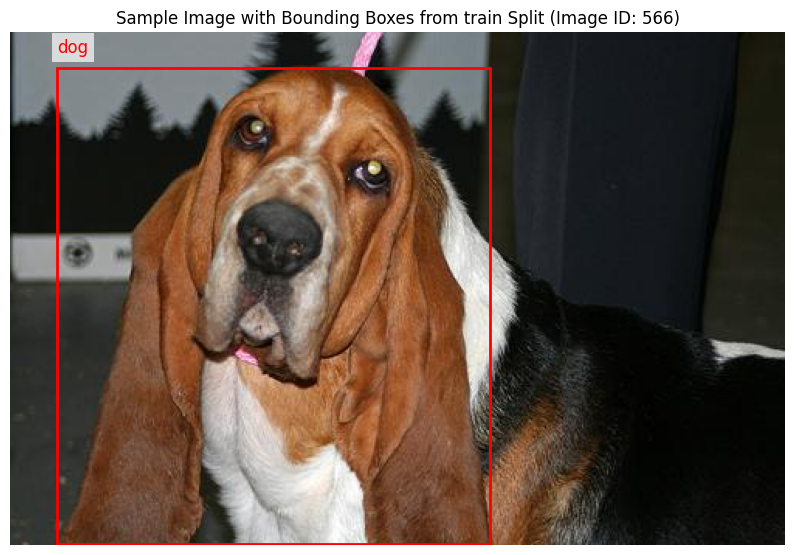

In [6]:
# Visualize a random image from the training dataset
visualize_random_image_with_bboxes(datasets, 'train')

In [7]:
class CNNLocalization(nn.Module):
    def __init__(self, num_classes=2): # num_classes=2 for cat and dog
        super(CNNLocalization, self).__init__()
        self.num_classes = num_classes # Store num_classes for use in forward pass
        # Convolutional layers
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # The input size to the first FC layer depends on the output size of the last conv/pool layer
        # For input 224x224, after 3 max pools (2x2), the spatial dimensions become 224/8 = 28
        # So, 128 channels * 28 * 28 spatial dimension
        self.fc_input_features = 128 * (224 // (2**3)) * (224 // (2**3)) # 128 * 28 * 28

        self.fc1 = nn.Linear(self.fc_input_features, 512)
        self.dropout = nn.Dropout(0.5)
        self.output = nn.Linear(512, self.num_classes + 4)

    def forward(self, x):
        # Conv -> BN -> ReLU -> Pool block 1
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        # Conv -> BN -> ReLU -> Pool block 2
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        # Conv -> BN -> ReLU -> Pool block 3
        x = self.pool(F.relu(self.bn3(self.conv3(x))))

        # Flatten the output for the fully connected layers
        x = x.view(-1, self.fc_input_features)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        output = self.output(x)

        # Split the output into classification logits and raw bounding box predictions
        class_logits = output[:, :self.num_classes]
        bbox_raw = output[:, self.num_classes:]

        # Apply sigmoid to bounding box predictions to ensure values are between 0 and 1
        bbox_predictions = torch.sigmoid(bbox_raw)

        # Concatenate back into a single tensor of size (batch_size, num_classes + 4)
        # The first `num_classes` elements are logits, and the next 4 are sigmoided bounding box coordinates.
        final_output = torch.cat((class_logits, bbox_predictions), dim=1)

        return final_output

# Instantiate the model
model = CNNLocalization(num_classes=2)

# Print the model architecture
print(model)

CNNLocalization(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=100352, out_features=512, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (output): Linear(in_features=512, out_features=6, bias=True)
)


In [8]:
# Define device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Move model to device
model.to(device)

# Define Loss Functions
classification_criterion = nn.CrossEntropyLoss()
bbox_criterion = nn.SmoothL1Loss()

# Define Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

Using device: cuda


In [23]:
num_epochs = 10
bbox_loss_weight = 10.0

def train_model(model, train_loader, val_loader, classification_criterion, bbox_criterion, optimizer, device, num_epochs, bbox_loss_weight):
    history = {'train_loss': [], 'val_loss': [], 'train_class_loss': [], 'val_class_loss': [], 'train_bbox_loss': [], 'val_bbox_loss': []}

    for epoch in range(num_epochs):
        model.train() # Set model to training mode
        running_train_loss = 0.0
        running_train_class_loss = 0.0
        running_train_bbox_loss = 0.0

        for i, (images, targets) in enumerate(train_loader):
            images = torch.stack(images).to(device)

            # Filter targets for bounding box loss: only consider images with actual boxes
            batch_class_labels_list = []
            batch_target_bboxes_list = []
            images_with_boxes_indices = []

            for k, t in enumerate(targets):
                # For classification, we assume every image has a primary label
                if t['labels'].numel() > 0:
                    batch_class_labels_list.append(t['labels'][0]) # Take the first label
                else:
                    batch_class_labels_list.append(torch.tensor(0, dtype=torch.int64)) # Default to class 0 if no labels

                if t['boxes'].numel() > 0:
                    batch_target_bboxes_list.append(t['boxes'][0]) # Take the first box as target
                    images_with_boxes_indices.append(k)

            batch_class_labels = torch.stack(batch_class_labels_list).to(device)

            optimizer.zero_grad()

            # Forward pass
            model_output = model(images)

            # Split output for classification and bounding box regression
            predicted_class_logits = model_output[:, :model.num_classes]
            predicted_bbox = model_output[:, model.num_classes:]

            # Calculate Classification Loss
            class_loss = classification_criterion(predicted_class_logits, batch_class_labels)

            # Calculate Bounding Box Loss (only for images that have ground truth boxes)
            bbox_loss = torch.tensor(0.0, device=device) # Initialize bbox_loss to 0
            if len(batch_target_bboxes_list) > 0:
                target_bbox_predictions = torch.stack(batch_target_bboxes_list).to(device)
                # Select predicted_bbox corresponding to images that had ground truth boxes
                predicted_bbox_for_loss = predicted_bbox[images_with_boxes_indices]
                bbox_loss = bbox_criterion(predicted_bbox_for_loss, target_bbox_predictions)

            # Combine losses
            total_loss = class_loss + (bbox_loss_weight * bbox_loss)

            # Backward pass and optimization
            total_loss.backward()
            optimizer.step()

            running_train_loss += total_loss.item()
            running_train_class_loss += class_loss.item()
            running_train_bbox_loss += bbox_loss.item()

            # Print mini-batch losses
            if (i + 1) % 100 == 0: # Print every 100 mini-batches
                print(f"  Epoch [{epoch+1}/{num_epochs}], Batch [{i+1}/{len(train_loader)}], "
                      f"Train Class Loss: {class_loss.item():.4f}, "
                      f"Train BBox Loss: {bbox_loss.item():.4f}")

        avg_train_loss = running_train_loss / len(train_loader)
        avg_train_class_loss = running_train_class_loss / len(train_loader)
        avg_train_bbox_loss = running_train_bbox_loss / len(train_loader)

        history['train_loss'].append(avg_train_loss)
        history['train_class_loss'].append(avg_train_class_loss)
        history['train_bbox_loss'].append(avg_train_bbox_loss)

        # --- Validation Loop ---
        model.eval() # Set model to evaluation mode
        running_val_loss = 0.0
        running_val_class_loss = 0.0
        running_val_bbox_loss = 0.0

        with torch.no_grad(): # Disable gradient calculations during validation
            for i, (images, targets) in enumerate(val_loader):
                images = torch.stack(images).to(device)

                batch_class_labels_list = []
                batch_target_bboxes_list = []
                images_with_boxes_indices = []

                for k, t in enumerate(targets):
                    if t['labels'].numel() > 0:
                        batch_class_labels_list.append(t['labels'][0])
                    else:
                        batch_class_labels_list.append(torch.tensor(0, dtype=torch.int64))

                    if t['boxes'].numel() > 0:
                        batch_target_bboxes_list.append(t['boxes'][0])
                        images_with_boxes_indices.append(k)

                batch_class_labels = torch.stack(batch_class_labels_list).to(device)

                model_output = model(images)

                predicted_class_logits = model_output[:, :model.num_classes]
                predicted_bbox = model_output[:, model.num_classes:]

                class_loss = classification_criterion(predicted_class_logits, batch_class_labels)

                bbox_loss = torch.tensor(0.0, device=device)
                if len(batch_target_bboxes_list) > 0:
                    target_bbox_predictions = torch.stack(batch_target_bboxes_list).to(device)
                    predicted_bbox_for_loss = predicted_bbox[images_with_boxes_indices]
                    bbox_loss = bbox_criterion(predicted_bbox_for_loss, target_bbox_predictions)

                total_loss = class_loss + (bbox_loss_weight * bbox_loss)

                running_val_loss += total_loss.item()
                running_val_class_loss += class_loss.item()
                running_val_bbox_loss += bbox_loss.item()

        avg_val_loss = running_val_loss / len(val_loader)
        avg_val_class_loss = running_val_class_loss / len(val_loader)
        avg_val_bbox_loss = running_val_bbox_loss / len(val_loader)

        history['val_loss'].append(avg_val_loss)
        history['val_class_loss'].append(avg_val_class_loss)
        history['val_bbox_loss'].append(avg_val_bbox_loss)

        print(f"Epoch [{epoch+1}/{num_epochs}], "
              f"Train Loss: {avg_train_loss:.4f} (Class: {avg_train_class_loss:.4f}, BBox: {avg_train_bbox_loss:.4f}), "
              f"Val Loss: {avg_val_loss:.4f} (Class: {avg_val_class_loss:.4f}, BBox: {avg_val_bbox_loss:.4f})")

    print("Training complete!")
    return history

In [24]:
print(f"Starting training for {num_epochs} epochs...")
training_history = train_model(
    model,
    data_loaders['train'],
    data_loaders['valid'],
    classification_criterion,
    bbox_criterion,
    optimizer,
    device,
    num_epochs,
    bbox_loss_weight=bbox_loss_weight
)


Starting training for 10 epochs...
  Epoch [1/10], Batch [100/322], Train Class Loss: 0.6689, Train BBox Loss: 0.0101
  Epoch [1/10], Batch [200/322], Train Class Loss: 0.6691, Train BBox Loss: 0.0097
  Epoch [1/10], Batch [300/322], Train Class Loss: 0.6697, Train BBox Loss: 0.0122
Epoch [1/10], Train Loss: 0.8395 (Class: 0.6244, BBox: 0.0108), Val Loss: 0.8598 (Class: 0.6407, BBox: 0.0110)
  Epoch [2/10], Batch [100/322], Train Class Loss: 0.6706, Train BBox Loss: 0.0076
  Epoch [2/10], Batch [200/322], Train Class Loss: 0.8571, Train BBox Loss: 0.0119
  Epoch [2/10], Batch [300/322], Train Class Loss: 0.6697, Train BBox Loss: 0.0146
Epoch [2/10], Train Loss: 0.8376 (Class: 0.6241, BBox: 0.0107), Val Loss: 0.8596 (Class: 0.6408, BBox: 0.0109)
  Epoch [3/10], Batch [100/322], Train Class Loss: 0.6717, Train BBox Loss: 0.0117
  Epoch [3/10], Batch [200/322], Train Class Loss: 0.6706, Train BBox Loss: 0.0101
  Epoch [3/10], Batch [300/322], Train Class Loss: 0.5730, Train BBox Loss: 0.0

In [25]:
def test_model(model, test_loader, classification_criterion, bbox_criterion, device, bbox_loss_weight):
    model.eval() # Set model to evaluation mode
    running_test_loss = 0.0
    running_test_class_loss = 0.0
    running_test_bbox_loss = 0.0
    correct_predictions = 0
    total_predictions = 0

    print("\nStarting evaluation on the test set...")

    with torch.no_grad(): # Disable gradient calculations
        for i, (images, targets) in enumerate(test_loader):
            images = torch.stack(images).to(device)

            batch_class_labels_list = []
            batch_target_bboxes_list = []
            images_with_boxes_indices = []

            for k, t in enumerate(targets):
                if t['labels'].numel() > 0:
                    batch_class_labels_list.append(t['labels'][0])
                else:
                    batch_class_labels_list.append(torch.tensor(0, dtype=torch.int64))

                if t['boxes'].numel() > 0:
                    batch_target_bboxes_list.append(t['boxes'][0])
                    images_with_boxes_indices.append(k)

            batch_class_labels = torch.stack(batch_class_labels_list).to(device)

            model_output = model(images)

            predicted_class_logits = model_output[:, :model.num_classes]
            predicted_bbox = model_output[:, model.num_classes:]

            # Classification Loss
            class_loss = classification_criterion(predicted_class_logits, batch_class_labels)

            # Bounding Box Loss
            bbox_loss = torch.tensor(0.0, device=device)
            if len(batch_target_bboxes_list) > 0:
                target_bbox_predictions = torch.stack(batch_target_bboxes_list).to(device)
                predicted_bbox_for_loss = predicted_bbox[images_with_boxes_indices]
                bbox_loss = bbox_criterion(predicted_bbox_for_loss, target_bbox_predictions)

            total_loss = class_loss + (bbox_loss_weight * bbox_loss)

            running_test_loss += total_loss.item()
            running_test_class_loss += class_loss.item()
            running_test_bbox_loss += bbox_loss.item()

            # Calculate accuracy
            _, predicted_classes = torch.max(predicted_class_logits, 1)
            total_predictions += batch_class_labels.size(0)
            correct_predictions += (predicted_classes == batch_class_labels).sum().item()

    avg_test_loss = running_test_loss / len(test_loader)
    avg_test_class_loss = running_test_class_loss / len(test_loader)
    avg_test_bbox_loss = running_test_bbox_loss / len(test_loader)
    accuracy = 100 * correct_predictions / total_predictions

    print(f"\nTest Results: "
          f"Avg Total Loss: {avg_test_loss:.4f}, "
          f"Avg Class Loss: {avg_test_class_loss:.4f}, "
          f"Avg BBox Loss: {avg_test_bbox_loss:.4f}, "
          f"Accuracy: {accuracy:.2f}%")


In [26]:
# Call the test_model function after training
test_model(
    model,
    data_loaders['test'],
    classification_criterion,
    bbox_criterion,
    device,
    bbox_loss_weight
)


Starting evaluation on the test set...

Test Results: Avg Total Loss: 0.8614, Avg Class Loss: 0.6423, Avg BBox Loss: 0.0110, Accuracy: 66.03%


In [27]:
def visualize_prediction_on_random_test_image(model, test_dataset, device, data_transform, class_names={0: 'cat', 1: 'dog'}):
    model.eval() # Set model to evaluation mode

    if len(test_dataset) == 0:
        print("Test dataset is empty. Cannot visualize predictions.")
        return

    # Get a random image index
    random_idx = random.randint(0, len(test_dataset) - 1)

    # Get the original image path
    original_img_path = test_dataset.image_paths[random_idx]
    original_image = Image.open(original_img_path).convert("RGB")

    # Get ground truth annotations for this image
    ground_truth_target = test_dataset.annotations.get(original_img_path, {'boxes': [], 'labels': []})

    # Apply the same transformations as during training/testing
    input_image = data_transform(original_image).unsqueeze(0).to(device) # Add batch dimension

    with torch.no_grad():
        model_output = model(input_image)

    # Process the model output
    predicted_class_logits = model_output[:, :model.num_classes]
    predicted_bbox_normalized = model_output[:, model.num_classes:]

    # Get predicted class (highest logit)
    _, predicted_class_idx = torch.max(predicted_class_logits, 1)
    predicted_class_label = predicted_class_idx.item()

    # Get predicted bounding box (it's already normalized [0,1] due to sigmoid)
    predicted_bbox = predicted_bbox_normalized.squeeze(0).cpu().numpy() # Remove batch dim, move to CPU, to numpy

    # Unnormalize predicted bounding box for visualization on the original image
    img_width, img_height = original_image.size
    xmin_abs_pred, ymin_abs_pred, xmax_abs_pred, ymax_abs_pred = unnormalize_bbox(predicted_bbox, float(img_width), float(img_height))

    # Plot the image and bounding boxes
    fig, ax = plt.subplots(1, figsize=(10, 10))
    ax.imshow(original_image)

    # Plot ground truth bounding boxes and labels (if any)
    if ground_truth_target['boxes']:
        for gt_box_norm, gt_label in zip(ground_truth_target['boxes'], ground_truth_target['labels']):
            xmin_abs_gt, ymin_abs_gt, xmax_abs_gt, ymax_abs_gt = unnormalize_bbox(gt_box_norm, float(img_width), float(img_height))
            gt_class_name = class_names.get(gt_label, f'Unknown ({gt_label})')

            # Create a Rectangle patch for the ground truth box (red)
            rect_gt = patches.Rectangle((xmin_abs_gt, ymin_abs_gt), xmax_abs_gt - xmin_abs_gt, ymax_abs_gt - ymin_abs_gt,
                                        linewidth=2, edgecolor='r', facecolor='none', linestyle='--')
            ax.add_patch(rect_gt)
            plt.text(xmin_abs_gt, ymin_abs_gt - 20, f'GT: {gt_class_name}', color='red', fontsize=12,
                     bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

    # Create a Rectangle patch for the predicted box (green)
    rect_pred = patches.Rectangle((xmin_abs_pred, ymin_abs_pred), xmax_abs_pred - xmin_abs_pred, ymax_abs_pred - ymin_abs_pred,
                                 linewidth=2, edgecolor='g', facecolor='none')
    ax.add_patch(rect_pred)

    # Add predicted class label
    predicted_class_name = class_names.get(predicted_class_label, f'Unknown ({predicted_class_label})')
    plt.text(xmin_abs_pred, ymin_abs_pred - 5, f'Pred: {predicted_class_name}', color='green', fontsize=12,
             bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

    ax.set_title(f"Model Prediction vs. Ground Truth on Test Image (Index: {random_idx})")
    plt.axis('off')
    plt.show()

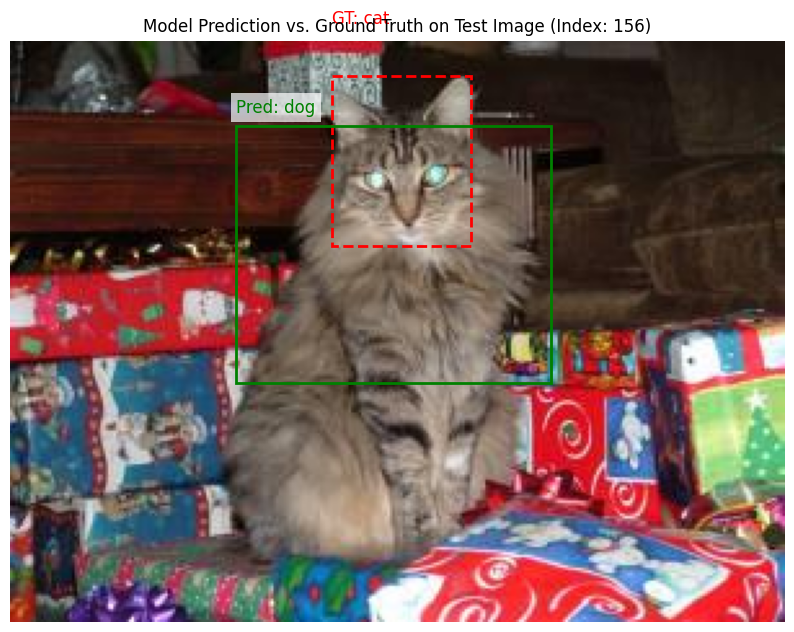

In [43]:
# Visualize a random prediction from the test dataset
visualize_prediction_on_random_test_image(model, datasets['test'], device, data_transform)

In [ ]:
# investigate the classification results

In [ ]:
# calculate IoU for the test set